In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score,GridSearchCV,train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install ydata_profiling

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("deforestation_dataset.csv")
df.head()

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,3,9.426264,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,4,2.602618,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,2,51.917315,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,4,23.716328,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,4,21.424037,159,41,18.085869


In [4]:
df.isnull().sum()

Country                            0
Year                               0
Forest_Loss_Area_km2               0
Tree_Cover_Loss_percent            0
CO2_Emission_mt                    0
Rainfall_mm                        0
Population                         0
GDP_Billion_USD                    0
Agriculture_Land_Percent           0
Deforestation_Policy_Strictness    0
Corruption_Index                   0
International_Aid_Million_USD      0
Illegal_Lumbering_Incidents        0
Protected_Areas_Percent            0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          100 non-null    object 
 1   Year                             100 non-null    int64  
 2   Forest_Loss_Area_km2             100 non-null    int64  
 3   Tree_Cover_Loss_percent          100 non-null    float64
 4   CO2_Emission_mt                  100 non-null    int64  
 5   Rainfall_mm                      100 non-null    float64
 6   Population                       100 non-null    int64  
 7   GDP_Billion_USD                  100 non-null    float64
 8   Agriculture_Land_Percent         100 non-null    float64
 9   Deforestation_Policy_Strictness  100 non-null    int64  
 10  Corruption_Index                 100 non-null    float64
 11  International_Aid_Million_USD    100 non-null    int64  
 12  Illegal_Lumbering_Incid

In [7]:
categorical_features = ["Country"]

numerical_features  =["Year",
    "Tree_Cover_Loss_percent",
    "CO2_Emission_mt",
    "Rainfall_mm",
    "Population",
    "GDP_Billion_USD",
    "Agriculture_Land_Percent",
    "Deforestation_Policy_Strictness",
    "Corruption_Index",
    "International_Aid_Million_USD",
    "Illegal_Lumbering_Incidents",
    "Protected_Areas_Percent"]

In [9]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(),numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"),categorical_features)
])

In [13]:
X = df.drop("Forest_Loss_Area_km2", axis=1)
y = df["Forest_Loss_Area_km2"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
X_train_processed= preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [19]:
X_train_processed.shape, X_test_processed.shape

((80, 17), (20, 17))

In [20]:
y_train.shape, y_test.shape

((80,), (20,))

In [22]:
svm = SVR(kernel="linear")

In [23]:
svm.fit(X_train_processed,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [24]:
y_pred = svm.predict(X_test_processed)

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1016.8128867788233
MSE : 1391332.93400606
RMSE: 1179.5477667335308
R²  : -0.3012413097516229


In [26]:
svm_poly = SVR(kernel="poly")
svm_poly.fit(X_train_processed, y_train)

y_pred_poly = svm_poly.predict(X_test_processed)

In [27]:
svm_rbf = SVR(kernel="rbf")
svm_rbf.fit(X_train_processed, y_train)

y_pred_rbf = svm_rbf.predict(X_test_processed)

In [28]:
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2

In [30]:
linear_results = evaluate_model(y_test, y_pred)
poly_results = evaluate_model(y_test, y_pred_poly)
rbf_results = evaluate_model(y_test, y_pred_rbf)

In [31]:
results = pd.DataFrame(
    [linear_results, poly_results, rbf_results],
    columns=["MAE", "MSE", "RMSE", "R2"],
    index=["Linear", "Polynomial", "RBF"]
)

results

,MAE,MSE,RMSE,R2
Linear,1016.812887,1.391333e+06,1179.547767,-0.301241
Polynomial,1012.050537,1.392763e+06,1180.153652,-0.302578
RBF,1012.031745,1.392562e+06,1180.068583,-0.302391


In [32]:
param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1]
}

In [35]:
grid_search= GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1

)

In [36]:
grid_search.fit(X_train_processed,y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 100, 'gamma': 1, 'kernel': 'rbf'}
-0.08864441663724665


In [37]:
best_svm = grid_search.best_estimator_
y_pred_best  = best_svm.predict(X_test_processed)

In [38]:
print("MAE :", mean_absolute_error(y_test, y_pred_best))
print("MSE :", mean_squared_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R²  :", r2_score(y_test, y_pred_best))

MAE : 1011.8900567365039
MSE : 1392305.6925702863
RMSE: 1179.9600385480376
R²  : -0.30215108022944914


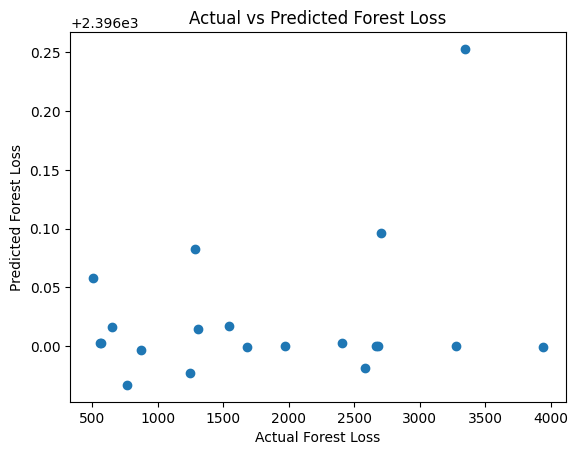

In [39]:
plt.scatter(y_test, y_pred_best)

plt.xlabel("Actual Forest Loss")
plt.ylabel("Predicted Forest Loss")
plt.title("Actual vs Predicted Forest Loss")

plt.show()

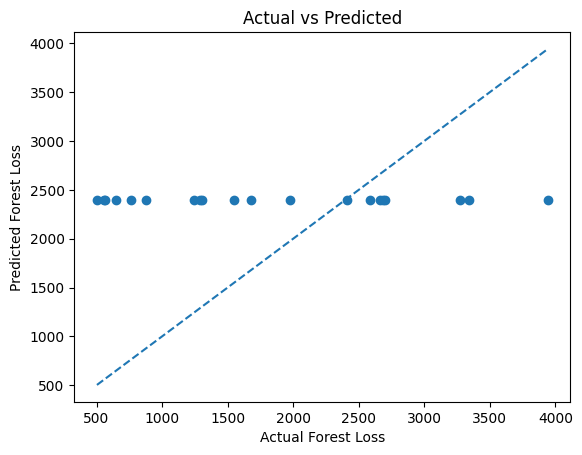

In [40]:
plt.scatter(y_test, y_pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Forest Loss")
plt.ylabel("Predicted Forest Loss")
plt.title("Actual vs Predicted")

plt.show()

In [42]:
svm.coef_

array([[ -5.14708544,  -5.21282356,  -0.65088722,  -2.6337738 ,
        -10.706376  ,   7.83701461, -18.22318575,   6.9515956 ,
          0.15731978,  -4.57790621,  11.38388208,   0.61767822,
          1.        ,   4.        ,  -1.        ,  -5.        ,
          1.        ]])

In [44]:
feature_names = preprocessor.get_feature_names_out()

coefficients = svm.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
6,num__Agriculture_Land_Percent,-18.223186,18.223186
10,num__Illegal_Lumbering_Incidents,11.383882,11.383882
4,num__Population,-10.706376,10.706376
5,num__GDP_Billion_USD,7.837015,7.837015
7,num__Deforestation_Policy_Strictness,6.951596,6.951596
1,num__Tree_Cover_Loss_percent,-5.212824,5.212824
0,num__Year,-5.147085,5.147085
15,cat__Country_Indonesia,-5.000000,5.000000
9,num__International_Aid_Million_USD,-4.577906,4.577906
13,cat__Country_Brazil,4.000000,4.000000


The Population, Policy Strictness, and Tree Cover Loss results are suspicious enough that you should investigate them.

For example, Deforestation_Policy_Strictness having a positive coefficient doesn't necessarily mean stricter policies cause more deforestation. It could mean countries experiencing severe deforestation subsequently introduce stricter policies.

That's reverse causality.

Similarly, if Tree_Cover_Loss_percent is mathematically or conceptually derived from the same underlying phenomenon as Forest_Loss_Area_km2, it could be a target-leakage/near-target feature. You should check how that column was generated before using it for a real predictive model.


The linear SVR model identified Agriculture Land Percentage, Illegal Lumbering Incidents, Population, GDP, and Deforestation Policy Strictness as the strongest predictors based on absolute coefficient magnitude. Illegal Lumbering Incidents showed a positive relationship with predicted forest loss, indicating that increased illegal logging activity is associated with greater forest loss. Agriculture Land Percentage showed the largest negative coefficient. GDP was positively associated with predicted forest loss, while International Aid showed a negative relationship. However, these coefficients represent model associations rather than causal effects. Unexpected relationships, particularly Population and Policy Strictness, should be interpreted cautiously because socioeconomic variables may be correlated with one another and policy responses may occur after deforestation has already increased.